In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset/training_set.npz


In [2]:
cd /kaggle/input/dataset/

/kaggle/input/dataset


# Import libraries and dataset

In [3]:
#%pip install tensorflow==2.17 keras==3.4.1
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import os 
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
#os.environ["CUDA_VISIBLE_DEVICES"]="0"

import tensorflow as tf
import keras as tfk
import keras_cv
from keras import layers as kl
from keras_cv import layers as kcvl
from keras import mixed_precision

#mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)  # Enable XLA

print("GPUs Available: ", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow version {tf.__version__}")

np.random.seed(42)
tf.random.set_seed(42)

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version 2.16.1


In [4]:
data = np.load('training_set.npz')

X = data['images']
y = data['labels']
print(X.shape, y.shape)

del data

(13759, 96, 96, 3) (13759, 1)


# 2 - Check for missing, duplicate values and class distribution

In [5]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [6]:
# Duplicates count and removal
reshaped_X = X.reshape(X.shape[0], -1) # Reshape each image to a 1D vector and stack them for comparison

unique_X, unique_indices = np.unique(reshaped_X, axis=0, return_index=True) # Find unique images and their indices

# Select unique images and labels
X_unique = X[unique_indices]
y_unique = y[unique_indices]

print(f'Labels reduced from {len(y)} to {len(y_unique)}')

Labels reduced from 13759 to 11953


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'Basophil'),
  Text(1, 0, 'Eosinophil'),
  Text(2, 0, 'Erythroblast'),
  Text(3, 0, 'Immature granulocytes'),
  Text(4, 0, 'Lymphocyte'),
  Text(5, 0, 'Monocyte'),
  Text(6, 0, 'Neutrophil'),
  Text(7, 0, 'Platelet')])

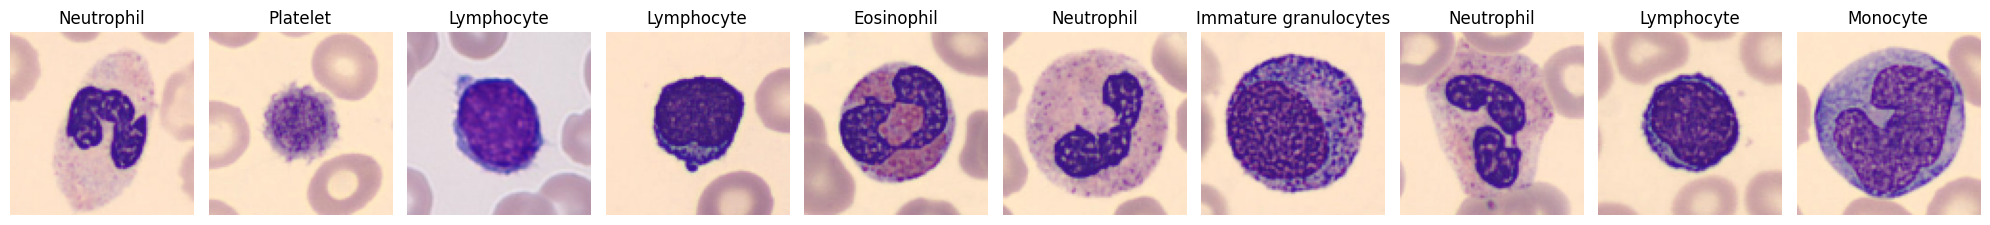

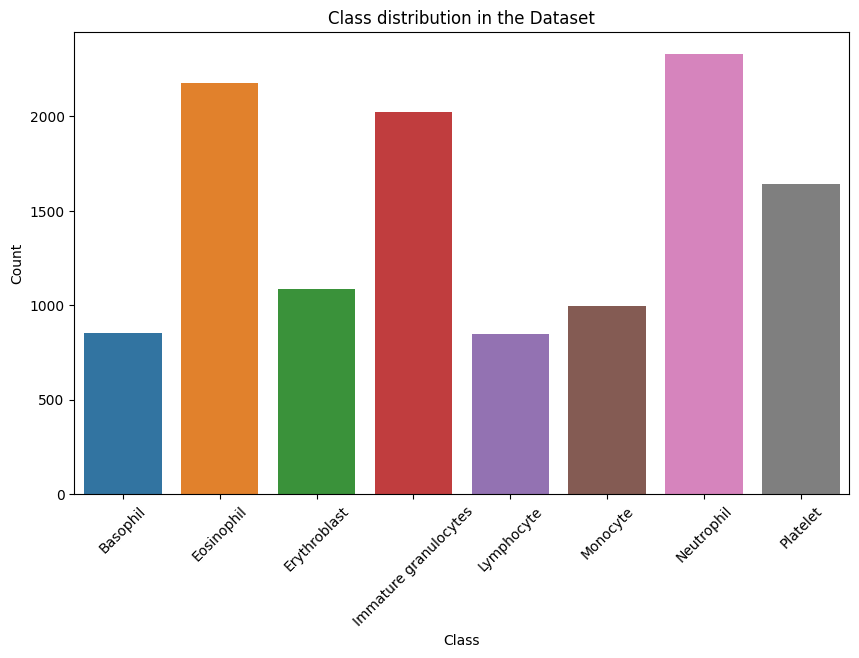

In [7]:
X = X_unique
y = y_unique

# Define a mapping of labels to their corresponding digit names
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Save unique labels
unique_labels = list(labels.values())

# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[y[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
#plt.show()

labels_list, counts = np.unique(y.flatten(), return_counts=True)
classes = [labels[label] for label in labels_list]
df = pd.DataFrame({'Class': classes, 'Count': counts})

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=counts)
plt.title('Class distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Adjust rotation for readability if needed
#plt.show()

# 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# Split data into training, test and validation sets, maintaining class distribution
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

# Convert labels to categorical format using one-hot encoding
y_train = tfk.utils.to_categorical(y_train)
y_val = tfk.utils.to_categorical(y_val)
#y_test = tfk.utils.to_categorical(y_test)

Training Data Shape: (8605, 96, 96, 3)
Training Label Shape: (8605, 1)
Test Data Shape: (2391, 96, 96, 3)
Test Label Shape: (2391, 1)
Validation Data Shape: (957, 96, 96, 3)
Validation Label Shape: (957, 1)


# 4 - Image Augmentation

In [9]:
value_range=(0, 255)
num_augmentations = 5  # Two random enhancements per image

# Define the enhancement layers
enhancement_layers = [
    kcvl.AutoContrast(value_range=value_range),
    kcvl.RandomHue(factor=0.2, value_range=value_range),
    kcvl.RandomSaturation(factor=0.5),
    kcvl.RandomSharpness(factor=0.3, value_range=value_range),
    kcvl.RandomColorDegeneration(factor=1.0),
    kcvl.RandomChannelShift(factor=0.2, value_range=value_range),
    kcvl.RandomShear(x_factor=0.1, y_factor=0.1),
    kcvl.Solarization(threshold_factor=0.5, value_range=value_range),
    kcvl.RandomRotation(factor=0.2),  # Adding Random Rotation
    kcvl.RandomZoom(height_factor=0.2, width_factor=0.2),  # Adding Random Zoom
    kcvl.RandomFlip(mode="horizontal_and_vertical"),  # Adding Random Flip
    kcvl.RandomBrightness(factor=0.2, value_range=value_range),  # Adding Random Brightness
    kcvl.RandomContrast(factor=0.2, value_range=value_range),  # Adding Random Contrast
    kcvl.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Adding Random Translation
]

# Define the random erasure function using TensorFlow operations
def random_erasure(images, min_area_ratio=0.02, max_area_ratio=0.33, probability=0.25):
    def erase(image):
        if tf.random.uniform(()) < probability:
            h, w, c = tf.shape(image)[0], tf.shape(image)[1], tf.shape(image)[2]
            area = tf.cast(h * w, tf.float32)
            target_area = tf.random.uniform((), min_area_ratio, max_area_ratio) * area
            aspect_ratio = tf.random.uniform((), 0.3, 1/0.3)
            erase_h = tf.cast(tf.sqrt(target_area * aspect_ratio), tf.int32)
            erase_w = tf.cast(tf.sqrt(target_area / aspect_ratio), tf.int32)
            if erase_h < h and erase_w < w:
                x = tf.random.uniform((), 0, w - erase_w, dtype=tf.int32)
                y = tf.random.uniform((), 0, h - erase_h, dtype=tf.int32)
                mask = tf.ones((erase_h, erase_w, c)) * tf.reduce_min(image)
                indices = tf.stack(tf.meshgrid(tf.range(y, y + erase_h), tf.range(x, x + erase_w), indexing='ij'), axis=-1)
                image = tf.tensor_scatter_nd_update(image, indices, mask)
        return image

    return tf.map_fn(erase, images, dtype=tf.float32)

# Define the augmentation pipeline
pipeline = kcvl.RandomAugmentationPipeline(
    layers=enhancement_layers,
    augmentations_per_image=num_augmentations
)

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])  # Apply RandomAugmentationPipeline
    inputs["images"] = random_erasure(inputs["images"])  # Apply Random Erasure
    return inputs

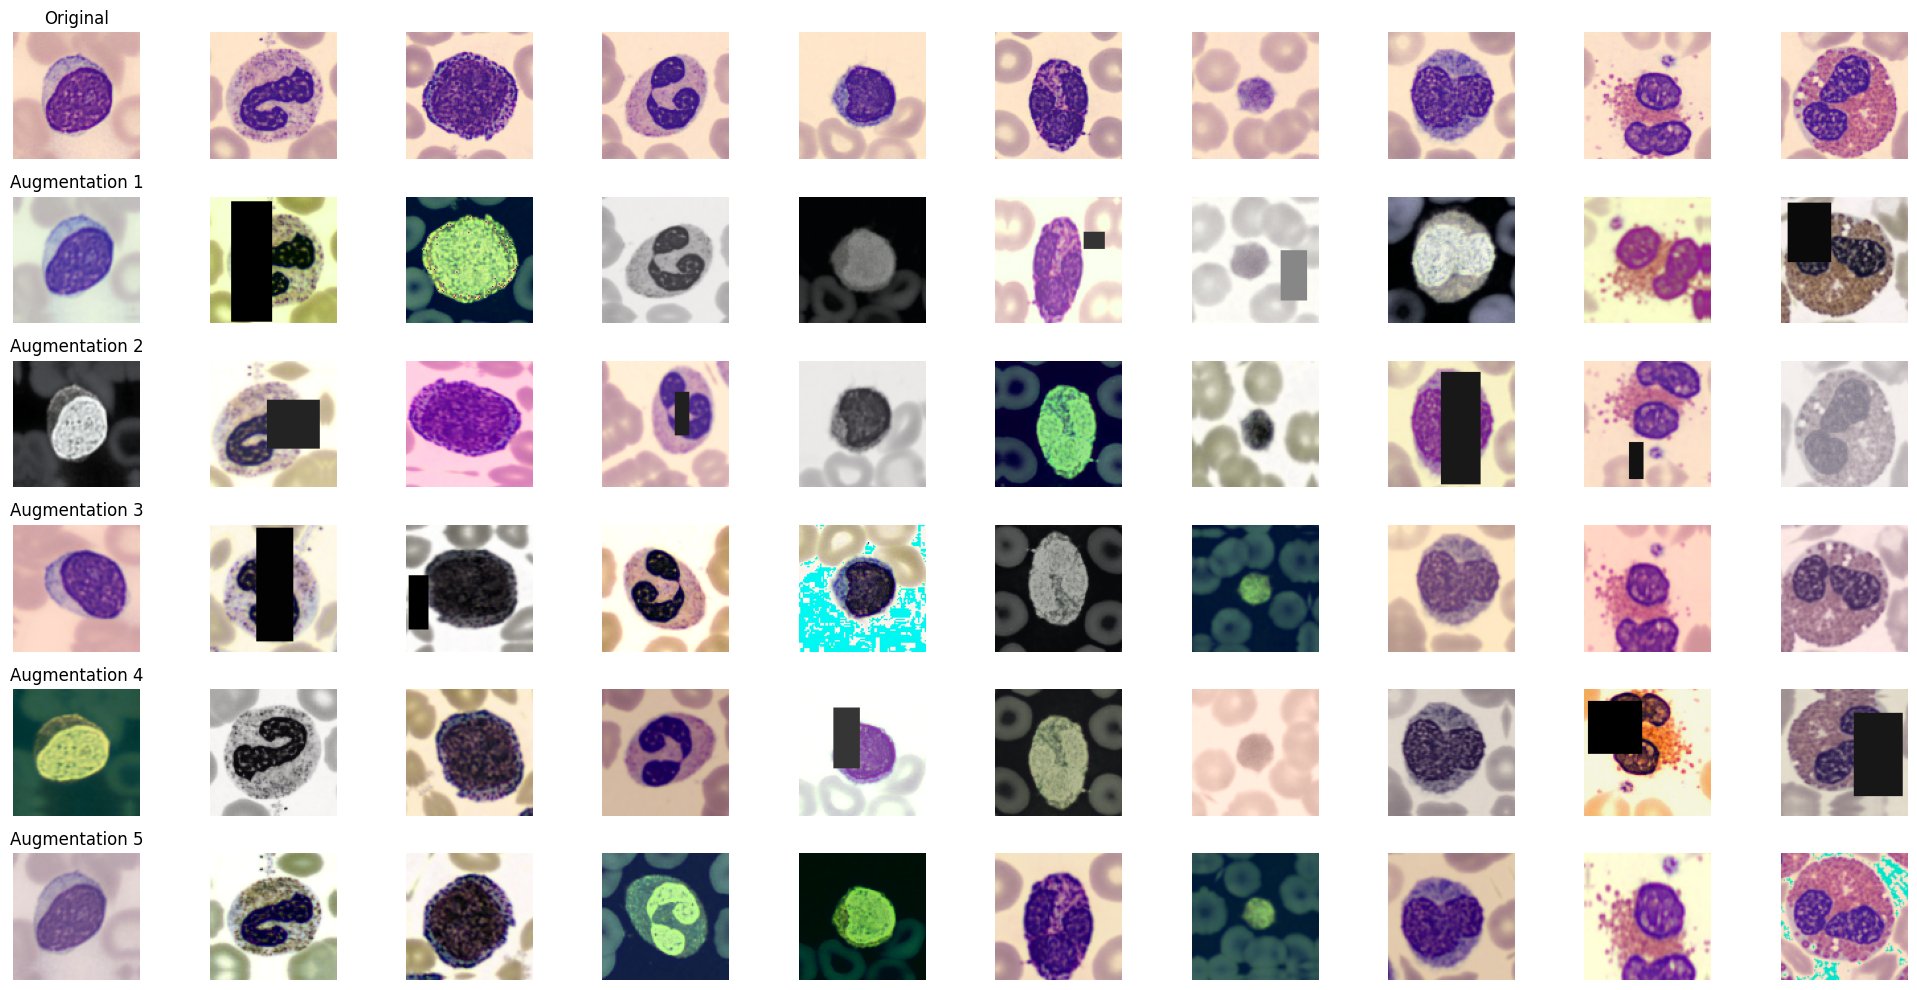

In [10]:
# Function to plot augmented images
def plot_augmented_images(X_train, y_train, num_images, num_augmentations):
    batch = X_train[:num_images]  # Take a batch of images for visualization
    labels_batch = y_train[:num_images]

    fig, axes = plt.subplots(num_augmentations + 1, num_images, figsize=(20, 10))  # 4 rows, 10 columns

    # Display original images in the first row
    for i in range(num_images):
        original_image = batch[i].astype("uint8")  # Convert to uint8 for display
        axes[0, i].imshow(original_image)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=12)
        else:
            axes[0, i].set_title("")

    # Display augmentations in subsequent rows
    for j in range(num_augmentations):
        augmented_batch = apply_pipeline({
            "images": tf.convert_to_tensor(batch),
            "labels": tf.convert_to_tensor(labels_batch, dtype=tf.float32)
        })
        for i in range(num_images):
            augmented_image = tf.clip_by_value(augmented_batch["images"][i], 0, 255)  # Ensure values are in display range
            axes[j + 1, i].imshow(augmented_image.numpy().astype("uint8"))
            axes[j + 1, i].axis("off")
            if i == 0:
                axes[j + 1, i].set_title(f"Augmentation {j + 1}", fontsize=12)
            else:
                axes[j + 1, i].set_title("")

    plt.tight_layout()
    plt.show()

# Plot 10 images with 4 augmented versions each
plot_augmented_images(X_train, y_train, 10, num_augmentations)

In [11]:
# Define the target size for the model (224x224 for MobileNetV2)
target_size = (224, 224)

normalization = 127.5 # 255 if [0, 1], 127.5 if [-1, 1] (used in MobileNetV2)
ran = 1 # 0 if [0, 1], 1 if [-1, 1] (used in MobileNetV2)

# Create a bicubic resizing layer
resize_layer = tf.keras.layers.Resizing(target_size[0], target_size[1], interpolation='bicubic')

batch_size = 32

# Create the train dataset
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(batch_size)
    .map(lambda x, y: (apply_pipeline({"images": x, "labels": tf.cast(y, tf.float32)})["images"], y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (resize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: ((x / normalization) - ran, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
    .prefetch(tf.data.AUTOTUNE)
)

# Create the validation dataset
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .map(lambda x, y: (resize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)  # Apply bicubic resizing
    .map(lambda x, y: ((x / normalization) - ran, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
    .prefetch(tf.data.AUTOTUNE)
)

# 5 - Build and Train the model

In [12]:
input_shape = (224,224,3)
output_shape = y_train.shape[1]

# Example of filter and stack configuration for each block
block_config = [
    {"filters": 16, "stack": 1, "downsample": False},  # Initial layer
    {"filters": 24, "stack": 2, "downsample": True},   # Second layer, downsamples
    {"filters": 40, "stack": 2, "downsample": True},   # Third layer, downsamples
    {"filters": 80, "stack": 3, "downsample": True},   # Fourth layer, downsamples
    {"filters": 112, "stack": 3, "downsample": False}, # Fifth layer
    {"filters": 160, "stack": 3, "downsample": True},  # Final layer, downsamples
]

print("Input Shape:", input_shape)
print("Output Shape:", output_shape)

Input Shape: (224, 224, 3)
Output Shape: 8


In [13]:
del X_train, y_train, X_val, y_val

In [14]:
from keras import layers as tfkl

# Define the MobileNetV3 block with configurable parameters
def mobilenetv3_block(x, filters, kernel_size=3, padding='same',
                      downsample=True, activation='h_swish', stack=1, name='mobilev3'):

    # Define h-swish activation function
    def h_swish(x):
        return x * tf.nn.relu6(x + 3.0) / 6.0

    # Select activation function
    activation_fn = tf.nn.relu if activation == 'relu' else h_swish

    for s in range(stack):
        input_channels = x.shape[-1]
        residual = x

        # Set expansion factor based on channel dimensions
        expansion_factor = 1 if input_channels == filters else 6
        expanded_channels = input_channels * expansion_factor

        # Expansion phase
        if expansion_factor != 1:
            x = tfkl.Conv2D(expanded_channels, 1, padding=padding, use_bias=False, name=f'{name}_expand_{s}')(x)
            x = tfkl.BatchNormalization(name=f'{name}_bn1_{s}')(x)
            x = tfkl.Activation(activation_fn, name=f'{name}_act1_{s}')(x)

        # Depthwise convolution with optional downsampling
        stride = 2 if (downsample and s == 0) else 1
        x = tfkl.DepthwiseConv2D(kernel_size, strides=stride, padding=padding, use_bias=False, name=f'{name}_depthwise_{s}')(x)
        x = tfkl.BatchNormalization(name=f'{name}_bn2_{s}')(x)
        x = tfkl.Activation(activation_fn, name=f'{name}_act2_{s}')(x)

        # Squeeze-and-Excitation module
        se_channels = max(1, expanded_channels // 4)
        se = tfkl.GlobalAveragePooling2D(name=f'{name}_se_pool_{s}')(x)
        se = tfkl.Reshape((1, 1, expanded_channels))(se)
        se = tfkl.Conv2D(se_channels, 1, activation='relu', name=f'{name}_se_reduce_{s}')(se)
        se = tfkl.Conv2D(expanded_channels, 1, activation='hard_sigmoid', name=f'{name}_se_expand_{s}')(se)
        x = tfkl.Multiply(name=f'{name}_se_excite_{s}')([x, se])

        # Projection phase to desired filter dimension
        x = tfkl.Conv2D(filters, 1, padding=padding, use_bias=False, name=f'{name}_project_{s}')(x)
        x = tfkl.BatchNormalization(name=f'{name}_bn3_{s}')(x)

        # Add skip connection if applicable
        if stride == 1 and input_channels == filters:
            x = tfkl.Add(name=f'{name}_add_{s}')([residual, x])

    return x

# Define the input layer and apply MobileNetV3 block
input_layer = tfkl.Input(shape=input_shape, name='input_layer')
#x = mobilenetv3_block(x=input_layer, filters=filters, kernel_size=kernel_size, downsample=False, name='block0', stack=stack)
x = input_layer

# Loop through each block configuration to build the model
for i, config in enumerate(block_config):
    x = mobilenetv3_block(
        x=x, 
        filters=config["filters"], 
        kernel_size=3,  # Choose 3 or 5 based on your preference
        downsample=config["downsample"], 
        stack=config["stack"], 
        name=f'block_{i}'
    )

# Global Average Pooling and fully connected output layer
x = tfkl.GlobalAveragePooling2D(name='gap')(x)
x = tfkl.Dense(output_shape, name='dense')(x)
x = tfkl.Activation('softmax', name='softmax')(x)

# Compile the model
model = tfk.Model(inputs=input_layer, outputs=x, name='architecture')
model.compile(loss=tfk.losses.CategoricalCrossentropy(), optimizer=tf.keras.optimizers.Lion(), metrics=['accuracy'])

# Display model summary and plot
model.summary(expand_nested=True, show_trainable=True)
#tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

Model: "architecture"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer       │ (None, 224,     │         0 │ -              │   -   │
│ (InputLayer)      │ 224, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_expand_0  │ (None, 224,     │        54 │ input_layer[0… │   Y   │
│ (Conv2D)          │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn1_0     │ (None, 224,     │        72 │ block_0_expan… │   Y   │
│ (BatchNormalizat… │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_act1_0    │ (None, 224,     │         0 │ block_0_bn1_0… │   -   │
│ (Activation)      │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_depthwis… │ (None, 224,     │       162 │ block_0_act1_… │   Y   │
│ (DepthwiseConv2D) │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn2_0     │ (None, 224,     │        72 │ block_0_depth… │   Y   │
│ (BatchNormalizat… │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_act2_0    │ (None, 224,     │         0 │ block_0_bn2_0… │   -   │
│ (Activation)      │ 224, 18)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_pool_0 │ (None, 18)      │         0 │ block_0_act2_… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ reshape (Reshape) │ (None, 1, 1,    │         0 │ block_0_se_po… │   -   │
│                   │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_reduc… │ (None, 1, 1, 4) │        76 │ reshape[0][0]  │   Y   │
│ (Conv2D)          │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_expan… │ (None, 1, 1,    │        90 │ block_0_se_re… │   Y   │
│ (Conv2D)          │ 18)             │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_se_excit… │ (None, 224,     │         0 │ block_0_act2_… │   -   │
│ (Multiply)        │ 224, 18)        │           │ block_0_se_ex… │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_project_0 │ (None, 224,     │       288 │ block_0_se_ex… │   Y   │
│ (Conv2D)          │ 224, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_0_bn3_0     │ (None, 224,     │        64 │ block_0_proje… │   Y   │
│ (BatchNormalizat… │ 224, 16)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_expand_0  │ (None, 224,     │     1,536 │ block_0_bn3_0… │   Y   │
│ (Conv2D)          │ 224, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_bn1_0     │ (None, 224,     │       384 │ block_1_expan… │   Y   │
│ (BatchNormalizat… │ 224, 96)        │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ block_1_act1_0    │ (None, 224,     │         0 │ block_1_bn1_0… │   - 

 Total params: 886,094 (3.38 MB)

 Trainable params: 875,558 (3.34 MB)

 Non-trainable params: 10,536 (41.16 KB)

In [15]:
mixed_precision.set_global_policy('mixed_float16')

In [16]:
epochs = 10000

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    train_dataset,
    #X_train, y_train,
    validation_data=val_dataset,
    #validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=[early_stopping, reduce_lr],
    #class_weight=adjusted_class_weights
).history

# Calculate and print the final validation accuracy
#final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)

# Save the trained model to a file with the accuracy included in the filename
model_filename = '/kaggle/working/CNN'+'.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/10000


I0000 00:00:1731841458.224217     101 service.cc:145] XLA service 0x5c16c922e000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731841458.224274     101 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1731841458.314594     101 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


269/269 ━━━━━━━━━━━━━━━━━━━━ 166s 439ms/step - accuracy: 0.3130 - loss: 1.8202 - val_accuracy: 0.0711 - val_loss: 54.0416 - learning_rate: 0.0010
Epoch 2/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 93s 336ms/step - accuracy: 0.7014 - loss: 0.8351 - val_accuracy: 0.4107 - val_loss: 9.3092 - learning_rate: 0.0010
Epoch 3/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 92s 331ms/step - accuracy: 0.8016 - loss: 0.5819 - val_accuracy: 0.5946 - val_loss: 2.8492 - learning_rate: 0.0010
Epoch 4/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 92s 329ms/step - accuracy: 0.8337 - loss: 0.4895 - val_accuracy: 0.6259 - val_loss: 1.9819 - learning_rate: 0.0010
Epoch 5/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 92s 331ms/step - accuracy: 0.8544 - loss: 0.4295 - val_accuracy: 0.8224 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 6/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 92s 330ms/step - accuracy: 0.8703 - loss: 0.3832 - val_accuracy: 0.8182 - val_loss: 0.5338 - learning_rate: 0.0010
Epoch 7/10000
269/269 ━━━━━━━━━━━━━━━━━━━━ 93s 333ms/step - accu

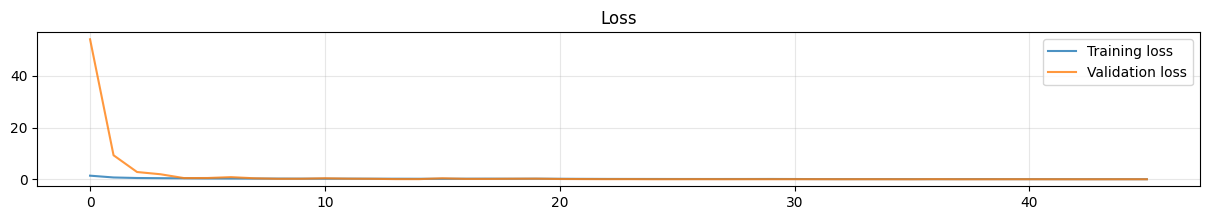

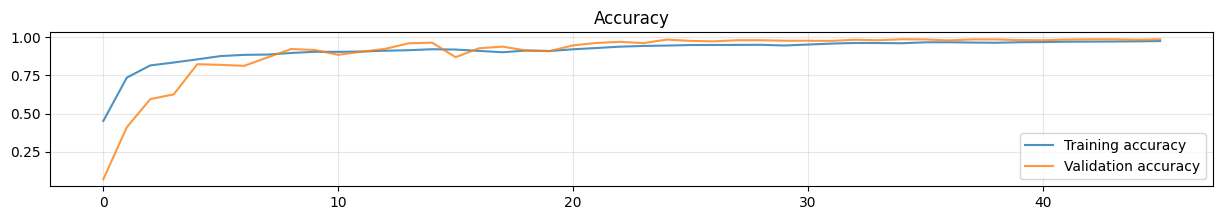

In [17]:
# Plot training and validation loss
plt.figure(figsize=(15, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title('Loss')
plt.legend()
plt.grid(alpha=.3)

# Plot training and validation accuracy
plt.figure(figsize=(15, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=.3)
plt.show()

# 6 - Evaluate the model

In [18]:
cd /kaggle/working

/kaggle/working


In [19]:
# Define h-swish activation function
def h_swish(x):
    return x * tf.nn.relu6(x + 3.0) / 6.0

# Load the saved model
model = tf.keras.models.load_model(model_filename, custom_objects={'h_swish': h_swish})

/opt/conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 166 variables whereas the saved optimizer has 162 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/conda/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:415: UserWarning: Skipping variable loading for optimizer 'lion', because it has 162 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
# Preprocess competition data
true_classes = y_test.flatten()

import cv2
normalized_X = (X_test / 127.5).astype('float32') - 1  # Normalize to [-1, 1]
resized_X = np.array([cv2.resize(img, (224, 224), interpolation=cv2.INTER_CUBIC) for img in normalized_X])

In [29]:
# Predict labels for the entire test set
predictions = model.predict(resized_X, verbose=0)

# Display the shape of the predictions
print("Predictions Shape:", predictions.shape)

Predictions Shape: (2391, 8)


In [30]:
predictions

array([[2.26229458e-05, 5.02964667e-07, 8.13555453e-05, ...,
        4.05787177e-05, 7.34489220e-07, 1.02625052e-06],
       [1.41028708e-11, 2.10634870e-08, 9.99713123e-01, ...,
        4.32272209e-08, 5.78903553e-07, 5.62377656e-09],
       [3.06463674e-11, 2.93674057e-10, 9.99951005e-01, ...,
        5.57604608e-07, 9.15392415e-11, 1.75263594e-07],
       ...,
       [8.35793032e-11, 8.81016931e-08, 4.10907264e-09, ...,
        9.99995947e-01, 3.28345322e-06, 5.60902547e-10],
       [1.45022550e-05, 1.02517845e-07, 9.89220098e-07, ...,
        3.65033003e-07, 2.27871215e-08, 9.99971747e-01],
       [1.69637843e-07, 7.62101706e-08, 7.36997299e-06, ...,
        2.74557942e-06, 1.61859534e-05, 9.99971032e-01]], dtype=float32)

Accuracy score over the test set: 0.9791
Precision score over the test set: 0.9792
Recall score over the test set: 0.9791
F1 score over the test set: 0.9791


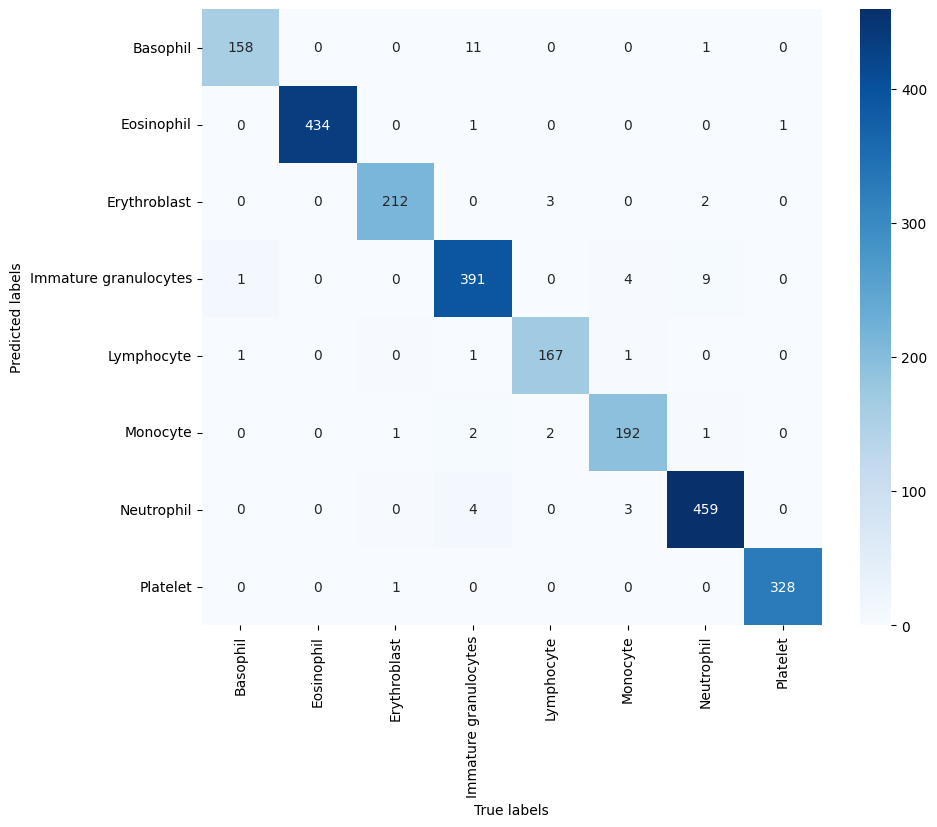

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

pred_classes = np.argmax(predictions, axis=-1)

# Calculate and display test set accuracy
accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

# Calculate and display test set precision
precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

# Calculate and display test set recall
recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

# Calculate and display test set F1 score
f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

# Compute the confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Combine numbers and percentages into a single string for annotation
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()

In [32]:
cd /kaggle/input/dataset/

/kaggle/input/dataset


In [33]:
model_filename = '/kaggle/input/dataset/CNN'+'.keras'
model.save(model_filename)

OSError: [Errno 30] Read-only file system: '/kaggle/input/dataset/CNN.keras'